## Purpose:
    This script evaluates route prediction accuracy by comparing observed validation
    routes with predicted routes generated by shortest-path, Basic Markov,
    Conditional Markov, and LSTM-based models.

## Input:
    - Validation route segment files:
      ./Jeju_data/Validation/shortcut_route/route_split_{k}/
    - Shortest-path baseline predictions:
      ./shortcut_prediction_route/shortcut_path_{k}.csv
    - Basic Markov predictions:
      ./prediction_markov/markov_route_{k}.csv
    - Conditional Markov predictions:
      ./prediction_markov_2/markov2_route_{k}.csv
    - Refined LSTM predictions:
      ./prediction_LSTM/LSTM_fix_{k}_by1.csv
    - Route split sizes:
      k = 8, 12, and 16

## Output:
    - Accuracy metric files:
      ./accuracy/accuracy_ver_last_{k}.csv
    - Jaccard similarity figure:
      ./similarity.png
    - Levenshtein distance figure:
      ./lenvenshtein.png

## Main procedures:
    1. Merge validation route segment files into traveler-level observed routes.
    2. Load predicted routes from each model.
    3. Compute Jaccard similarity between observed and predicted node sets.
    4. Compute Levenshtein distance between observed and predicted node sequences.
    5. Save accuracy metrics for each route split size.
    6. Visualize model-level distributions of Jaccard similarity and Levenshtein distance.

In [ ]:
import numpy as np
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

In [ ]:
def jaccard_similarity(base, compare_set):
    intersection = len(base.intersection(compare_set))
    union = len(base.union(compare_set))
    return intersection / union

def levenshtein(s1, s2):
    len1, len2 = len(s1), len(s2)
    dp = np.zeros((len1 + 1, len2 + 1), dtype=int)

    for i in range(len1 + 1):
        dp[i][0] = i
    for j in range(len2 + 1):
        dp[0][j] = j

    for i in range(1, len1 + 1):
        for j in range(1, len2 + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1,     # deletion
                           dp[i][j-1] + 1,     # insertion
                           dp[i-1][j-1] + cost)  # substitution

    return dp[len1][len2]

In [ ]:
def numerical_sort_key(file):
    return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', file)]

for k in [8, 12, 16]:
    ROOT = f"Jeju_data/Validation/shortcut_route/route_split_{k}"
    csv_files = sorted(glob.glob(os.path.join(ROOT, "*.csv")), key=numerical_sort_key)

    # Accumulate route segments by traveler name in file order.
    routes_by_name = {}

    for f in csv_files:
        try:
            df = pd.read_csv(f)
        except UnicodeDecodeError:
            df = pd.read_csv(f, encoding="utf-8-sig")

        for name, g in df.groupby("name"):
            route_list = [int(x) for x in g["path"].tolist()]
            routes_by_name.setdefault(name, []).append(route_list)

    # Merge route segments while removing duplicated boundary nodes.
    def merge_routes(route_chunks):
        if not route_chunks:
            return []
        merged = list(route_chunks[0])
        for nxt in route_chunks[1:]:
            if not nxt:
                continue
            if merged and nxt:
                # If consecutive segments share a boundary node, remove the duplicated node.
                if merged[-1] == nxt[0]:
                    merged.extend(nxt[1:])
                else:
                    merged.extend(nxt)
            else:
                merged.extend(nxt)
        return merged

    # Merge all route chunks for each traveler.
    records = []
    for name, chunks in routes_by_name.items():
        merged_route = merge_routes(chunks)
        records.append({"travel_name": name, "route": merged_route})

    # DataFrame
    out_df = pd.DataFrame(records, columns=["travel_name", "route"])
    OUT_PATH = os.path.join(f"merged_routes_by_{k}.csv")
    out_df.to_csv(OUT_PATH, index=False)

    print(f"완료: {len(out_df)}개 travel_name 병합 → {OUT_PATH}")


In [ ]:
for i in range(8, 17, 4):
    shortcut_pd = pd.read_csv(f'./shortcut_prediction_route/shortcut_path_{i}.csv')
    LSTM_pd = pd.read_csv(f'./prediction_LSTM/LSTM_fix_{i}_by1.csv')
    gps_pd = pd.read_csv(f'./merged_routes_by_{i}.csv')
    marcov_pd = pd.read_csv(f'./prediction_markov/markov_route_{i}.csv')
    marcov_2_pd = pd.read_csv(f'./prediction_markov_2/markov2_route_{i}.csv')
    
    similarity_sc_all = []
    levenshtein_distnace_sc_all = []
    similarity_LSTM_all = []
    levenshtein_distnace_LSTM_all = []
    similarity_marcov_all = []
    levenshtein_distnace_marcov_all = []
    similarity_marcov_2_all = []
    levenshtein_distnace_marcov_2_all = []

    for j in range(len(gps_pd)):
        # Observed validation route.
        gps_route = ast.literal_eval(gps_pd.iloc[j, 1])
        gps_name = gps_pd.iloc[j, 0]
        # Shortest-path baseline prediction.
        shortcut_route = ast.literal_eval(shortcut_pd[shortcut_pd['name'] == gps_name]['path'].iloc[0])
        # LSTM prediction.
        LSTM_route = ast.literal_eval(LSTM_pd[LSTM_pd['name'] == gps_name]['path'].iloc[0])
        # Basic Markov prediction.
        marcov_route = ast.literal_eval(marcov_pd[marcov_pd['travel_name'] == gps_name]['predicted_route'].iloc[0])
        # Conditional Markov prediction.
        marcov_2_route = ast.literal_eval(marcov_2_pd[marcov_2_pd['travel_name'] == gps_name]['predicted_route'].iloc[0])

        # calculate similarity and distance metrics
        base = set(gps_route)
        compare_sc = set(shortcut_route)
        compare_LSTM = set(LSTM_route)
        compare_marcov = set(marcov_route)
        compare_marcov_2 = set(marcov_2_route)

        similarity_sc = jaccard_similarity(base, compare_sc)
        levenshtein_distnace_sc = levenshtein(gps_route, shortcut_route)
        similarity_LSTM = jaccard_similarity(base, compare_LSTM)
        levenshtein_distnace_LSTM = levenshtein(gps_route, LSTM_route)
        similarity_marcov = jaccard_similarity(base, compare_marcov)
        levenshtein_distnace_marcov = levenshtein(gps_route, marcov_route)
        similarity_marcov_2 = jaccard_similarity(base, compare_marcov_2)
        levenshtein_distnace_marcov_2 = levenshtein(gps_route, marcov_2_route)
        

        similarity_sc_all.append(similarity_sc)
        levenshtein_distnace_sc_all.append(levenshtein_distnace_sc)
        similarity_LSTM_all.append(similarity_LSTM)
        levenshtein_distnace_LSTM_all.append(levenshtein_distnace_LSTM)
        similarity_marcov_all.append(similarity_marcov)
        levenshtein_distnace_marcov_all.append(levenshtein_distnace_marcov)
        similarity_marcov_2_all.append(similarity_marcov_2)
        levenshtein_distnace_marcov_2_all.append(levenshtein_distnace_marcov_2)

    data = {
        'similarity_sc': similarity_sc_all,
        'levenshtein_sc': levenshtein_distnace_sc_all,
        'similarity_LSTM': similarity_LSTM_all,
        'levenshtein_LSTM': levenshtein_distnace_LSTM_all,
        'similarity_markov': similarity_marcov_all,
        'levenshtein_markov': levenshtein_distnace_marcov_all
        ,'similarity_markov_2': similarity_marcov_2_all,
        'levenshtein_markov_2': levenshtein_distnace_marcov_2_all
    }

    df = pd.DataFrame(data)
    df.to_csv(f'./accuracy/accuracy_ver_last_{i}.csv', index=False)

## Visualization

### Jaccard Similarity

/tmp/ipykernel_1481448/911669610.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


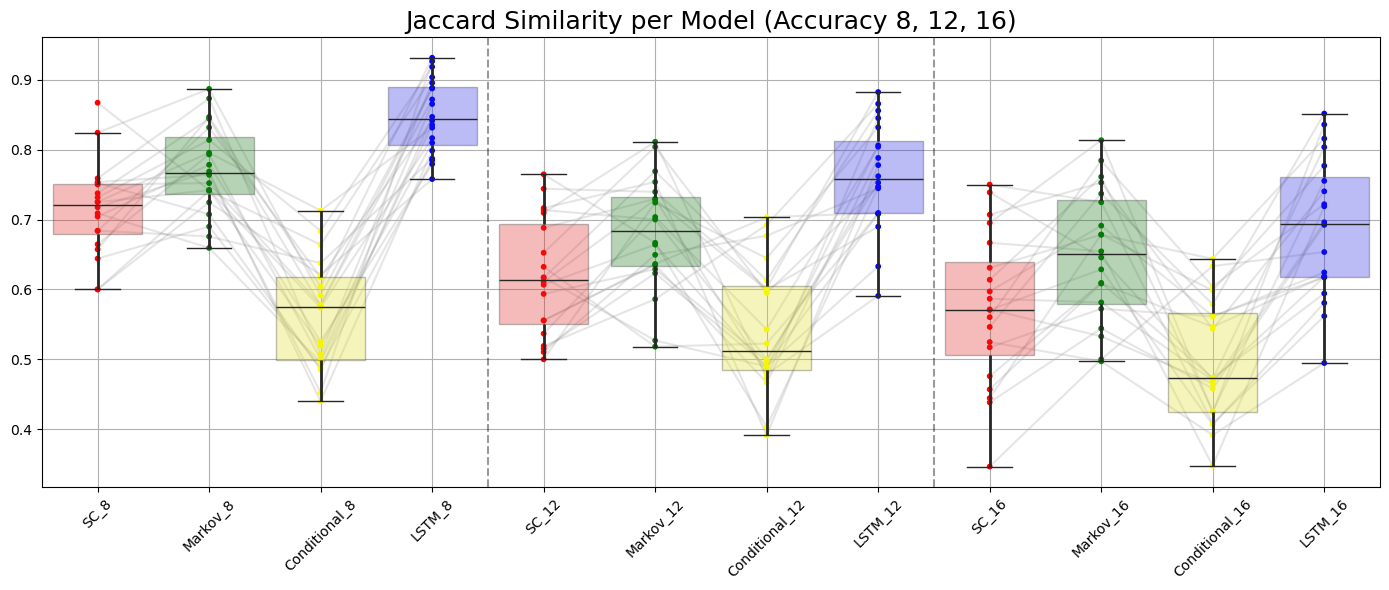

In [ ]:
df_long_all = []
pair_lines = []

for i in range(8, 17, 4):  # 8, 12, 16
    file_path = f'./accuracy/accuracy_ver_last_{i}.csv'
    if os.path.exists(file_path):
        df_tmp = pd.read_csv(file_path)

        # column selection: 0=Shortest-path, 2=LSTM, 4=Markov, 6=Conditional Markov
        df_tmp = df_tmp.iloc[:, [0, 2, 4, 6]]
        df_tmp.columns = [f'SC_{i}', f'LSTM_{i}', f'Markov_{i}', f'Markov_2_{i}']
        df_tmp['SampleID'] = df_tmp.index

        df_long = df_tmp.melt(
            id_vars='SampleID',
            var_name='Method',
            value_name='Distance'
        )
        df_long_all.append(df_long)

        # line info for paired samples (same SampleID across methods)
        for _, row in df_tmp.iterrows():
            pair_lines.append({
                'x': [f'SC_{i}', f'Markov_{i}', f'Markov_2_{i}', f'LSTM_{i}'],
                'y': [row[f'SC_{i}'], row[f'Markov_{i}'], row[f'Markov_2_{i}'], row[f'LSTM_{i}']]
            })
    else:
        print(f"File not found: {file_path}")

if df_long_all:
    df_long_all = pd.concat(df_long_all, ignore_index=True)

    plt.figure(figsize=(14, 6), facecolor="none")
    ax = plt.gca()
    ax.set_facecolor("none")

    # chart order: SC, Markov, Markov_2, LSTM (for each accuracy group)
    method_order = ['SC', 'Markov', 'Markov_2', 'LSTM']

    xticks = sorted(
        df_long_all['Method'].unique(),
        key=lambda x: (
            int(x.split('_')[-1]),
            method_order.index(x.rsplit('_', 1)[0])
        )
    )

    xmap = {label: idx for idx, label in enumerate(xticks)}
    num_groups = len(xticks) // 4

    # paired line plot for each sample across methods
    for line in pair_lines:
        x_vals = [xmap[m] for m in line['x']]
        y_vals = line['y']
        plt.plot(x_vals, y_vals, color='gray', alpha=0.2, zorder=1)
        plt.scatter(
            x_vals, y_vals,
            color=['red', 'green', 'yellow', 'blue'],
            s=10,
            zorder=2
        )

    # vertical lines to separate accuracy groups
    for g in range(1, num_groups):
        plt.axvline(x=g * 4 - 0.5, color='black', linestyle='--', alpha=0.4)

    sns.boxplot(
        data=df_long_all,
        x='Method',
        y='Distance',
        order=xticks,
        palette=['red', 'green', 'yellow', 'blue'] * num_groups,
        boxprops=dict(alpha=0.3),
        showcaps=True,
        whiskerprops={'linewidth': 2},
        fliersize=0
    )

    plt.title("Jaccard Similarity per Model (Accuracy 8, 12, 16)", fontsize=18)
    plt.xlabel("")
    plt.ylabel("")

    labels = [lab.replace("Markov_2", "Conditional") for lab in xticks]
    ax.set_xticks(range(len(xticks)))
    ax.set_xticklabels(labels, rotation=45)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig("similarity.png", transparent=True, dpi=300)
    plt.show()

### Levenshtein Distance

/tmp/ipykernel_1481448/477634756.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


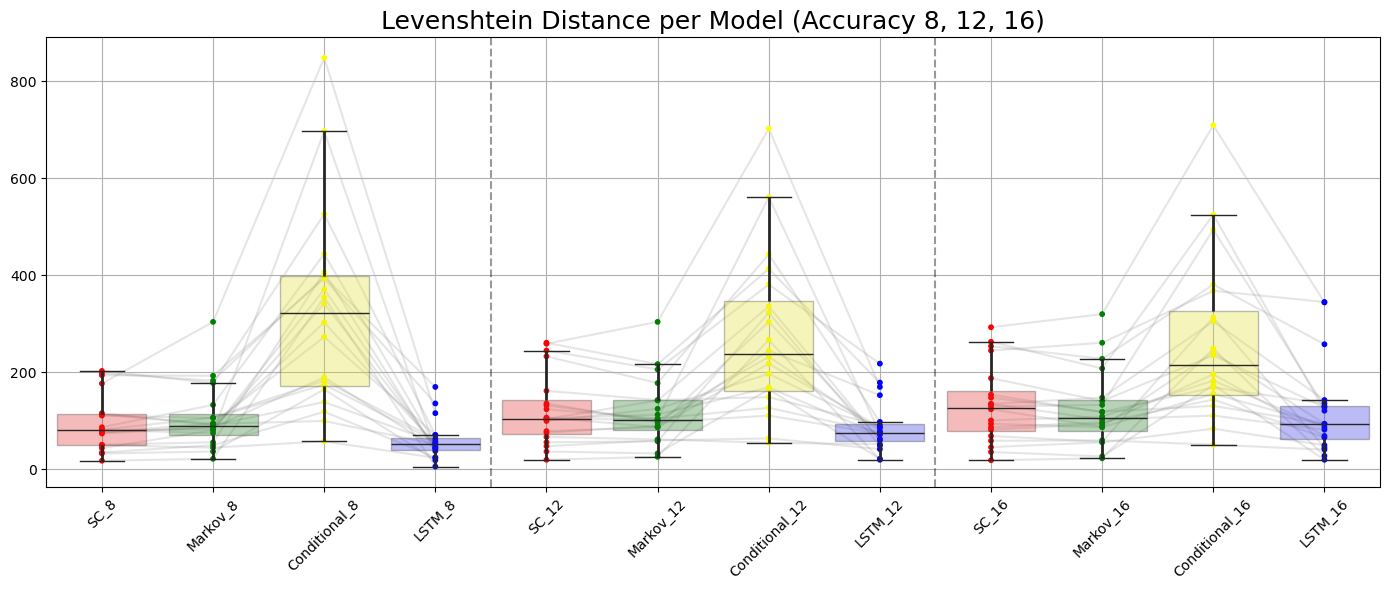

In [ ]:
df_long_all = []
pair_lines = []

for i in range(8, 17, 4):
    file_path = f'./accuracy/accuracy_ver_last_{i}.csv'
    if os.path.exists(file_path):
        df_tmp = pd.read_csv(file_path)

        # column selection
        df_tmp = df_tmp.iloc[:, [1, 3, 5, 7]]
        df_tmp.columns = [f'SC_{i}', f'LSTM_{i}', f'Markov_{i}', f'Markov_2_{i}']
        df_tmp['SampleID'] = df_tmp.index

        df_long = df_tmp.melt(
            id_vars='SampleID',
            var_name='Method',
            value_name='Distance'
        )
        df_long_all.append(df_long)

        for _, row in df_tmp.iterrows():
            pair_lines.append({
                'x': [f'SC_{i}', f'Markov_{i}', f'Markov_2_{i}', f'LSTM_{i}'],
                'y': [row[f'SC_{i}'], row[f'Markov_{i}'], row[f'Markov_2_{i}'], row[f'LSTM_{i}']]
            })
    else:
        print(f"File not found: {file_path}")

if df_long_all:
    df_long_all = pd.concat(df_long_all, ignore_index=True)

    plt.figure(figsize=(14, 6), facecolor="none")
    ax = plt.gca()
    ax.set_facecolor("none")

    method_order = ['SC', 'Markov', 'Markov_2', 'LSTM']

    xticks = sorted(
        df_long_all['Method'].unique(),
        key=lambda x: (
            int(x.split('_')[-1]),
            method_order.index(x.rsplit('_', 1)[0])
        )
    )

    xmap = {label: idx for idx, label in enumerate(xticks)}
    num_groups = len(xticks) // 4

    for line in pair_lines:
        x_vals = [xmap[m] for m in line['x']]
        y_vals = line['y']
        plt.plot(x_vals, y_vals, color='gray', alpha=0.2, zorder=1)
        plt.scatter(
            x_vals, y_vals,
            color=['red', 'green', 'yellow', 'blue'],
            s=10,
            zorder=2
        )

    for g in range(1, num_groups):
        plt.axvline(x=g * 4 - 0.5, color='black', linestyle='--', alpha=0.4)

    sns.boxplot(
        data=df_long_all,
        x='Method',
        y='Distance',
        order=xticks,
        palette=['red', 'green', 'yellow', 'blue'] * num_groups,
        boxprops=dict(alpha=0.3),
        showcaps=True,
        whiskerprops={'linewidth': 2},
        fliersize=0
    )

    plt.title("Levenshtein Distance per Model (Accuracy 8, 12, 16)", fontsize=18)

    plt.xlabel("")
    plt.ylabel("")

    labels = [lab.replace("Markov_2", "Conditional") for lab in xticks]
    ax.set_xticks(range(len(xticks)))
    ax.set_xticklabels(labels, rotation=45)

    plt.grid(True)
    plt.tight_layout()

    plt.savefig("lenvenshtein.png", transparent=True, dpi=300)
    plt.show()